# Payment Fraud Detection

This notebook builds a fraud detection model using PaySim-style payment data. The aim is to create a project that is technically strong but still easy to explain in an interview.

The workflow is:

1. Load and inspect the transaction data.
2. Remove fields that could leak information from after the transaction.
3. Build simple historical behaviour features using only earlier time steps.
4. Split the data chronologically into train, validation and test sets.
5. Compare Logistic Regression, Random Forest and XGBoost.
6. Evaluate the models using precision-recall metrics rather than accuracy.
7. Choose a review threshold based on a fixed investigation capacity.
8. Inspect feature importance and model performance over time.
9. Save the final model for later deployment.

The README explains the reasoning behind each section in more detail.

## 1. Imports and settings

This section loads the libraries used throughout the notebook and defines a few project settings. The review capacity is set to 1%, meaning we assume a fraud team can manually inspect the highest-risk 1% of transactions.

In [1]:
from pathlib import Path
import json
import math
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

RANDOM_STATE = 42
REVIEW_CAPACITY = 0.01
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

## 2. Load the data

Change `DATA_PATH` to point to the PaySim CSV on your machine. The project also includes a small synthetic PaySim-shaped file so the notebook can be tested without downloading the full dataset first.

In [2]:
DATA_PATH = Path('data/PaySim.csv')

if not DATA_PATH.exists():
    DATA_PATH = Path('demo_paysim.csv')

required_columns = {
    'step', 'type', 'amount', 'nameOrig', 'nameDest', 'isFraud'
}

df = pd.read_csv(DATA_PATH)
missing = required_columns - set(df.columns)

if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')

df = df.sort_values('step', kind='stable').reset_index(drop=True)
df['isFraud'] = df['isFraud'].astype(int)

print(f'Dataset: {DATA_PATH}')
print(f'Transactions: {len(df):,}')
print(f'Fraud cases: {df["isFraud"].sum():,}')
print(f'Fraud rate: {df["isFraud"].mean():.4%}')
df.head()

Dataset: demo_paysim.csv
Transactions: 6,000
Fraud cases: 65
Fraud rate: 1.0833%


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,CASH_OUT,772.07,C000174,2095.71,1323.64,M000028,1613.82,2385.90,0,0
1,1,PAYMENT,158.99,C000114,4019.83,3860.84,M000089,9563.62,9722.62,0,0
2,1,PAYMENT,620.62,C000183,3192.86,2572.25,M000097,667.99,1288.61,0,0
3,1,PAYMENT,587.00,C000008,2880.36,2293.36,M000103,6414.32,7001.32,0,0
4,1,CASH_OUT,2844.24,C000239,737.20,0.00,M000120,41462.55,44306.79,0,0


## 3. Basic exploration and leakage check

PaySim contains some columns that should not be used directly for prediction. In particular, `newbalanceOrig` and `newbalanceDest` describe balances after the transaction, while `isFlaggedFraud` represents an existing fraud rule. Using these fields would make the model look better without representing a realistic prediction problem.

Account IDs are also not given directly to the model. They are only used to calculate historical behaviour.

In [3]:
leakage_columns = ['newbalanceOrig', 'newbalanceDest', 'isFlaggedFraud']
identifier_columns = ['nameOrig', 'nameDest']

leakage_report = pd.DataFrame({
    'column': leakage_columns + identifier_columns,
    'use_in_model': [False, False, False, False, False],
    'reason': [
        'Post-transaction balance',
        'Post-transaction balance',
        'Existing fraud rule',
        'Used only to create sender history',
        'Used only to create recipient and pair history',
    ]
})

leakage_report

,column,use_in_model,reason
0,newbalanceOrig,False,Post-transaction balance
1,newbalanceDest,False,Post-transaction balance
2,isFlaggedFraud,False,Existing fraud rule
3,nameOrig,False,Used only to create sender history
4,nameDest,False,Used only to create recipient and pair history


In [4]:
fraud_by_type = (
    df.groupby('type')['isFraud']
      .agg(['count', 'sum', 'mean'])
      .rename(columns={'count': 'transactions', 'sum': 'frauds', 'mean': 'fraud_rate'})
      .sort_values('fraud_rate', ascending=False)
)

fraud_by_type

,transactions,frauds,fraud_rate
type,,,
CASH_OUT,1333,25,0.018755
TRANSFER,1247,23,0.018444
PAYMENT,2320,13,0.005603
CASH_IN,872,4,0.004587
DEBIT,228,0,0.000000


## 4. Historical feature engineering

The main idea is to describe how unusual a transaction is compared with the customer's earlier behaviour.

PaySim's `step` is an hourly time index. To avoid using information from the future, each historical feature is calculated from steps strictly before the current step. Transactions in the same hour therefore do not influence one another.

The features are deliberately simple: previous transaction counts, previous average amount, whether the recipient is new, the number of earlier transactions between the same sender and recipient, and the time since the sender was previously active.

In [5]:
def build_history_features(data):
    data = data.copy()
    data['log_amount'] = np.log1p(data['amount'].clip(lower=0))
    data['hour'] = data['step'] % 24

    sender_step = (
        data.groupby(['nameOrig', 'step'], as_index=False)
            .agg(step_count=('amount', 'size'), step_amount=('amount', 'sum'))
            .sort_values(['nameOrig', 'step'])
    )
    sender_group = sender_step.groupby('nameOrig')
    sender_step['sender_tx_count_before'] = sender_group['step_count'].cumsum() - sender_step['step_count']
    sender_step['sender_amount_sum_before'] = sender_group['step_amount'].cumsum() - sender_step['step_amount']
    sender_step['sender_previous_step'] = sender_group['step'].shift(1)

    sender_step['sender_mean_amount_before'] = np.where(
        sender_step['sender_tx_count_before'] > 0,
        sender_step['sender_amount_sum_before'] / sender_step['sender_tx_count_before'],
        0.0,
    )
    sender_step['hours_since_sender_tx'] = (
        sender_step['step'] - sender_step['sender_previous_step']
    ).fillna(10_000)

    recipient_step = (
        data.groupby(['nameDest', 'step'], as_index=False)
            .size()
            .rename(columns={'size': 'step_count'})
            .sort_values(['nameDest', 'step'])
    )
    recipient_step['recipient_tx_count_before'] = (
        recipient_step.groupby('nameDest')['step_count'].cumsum()
        - recipient_step['step_count']
    )

    pair_step = (
        data.groupby(['nameOrig', 'nameDest', 'step'], as_index=False)
            .size()
            .rename(columns={'size': 'step_count'})
            .sort_values(['nameOrig', 'nameDest', 'step'])
    )
    pair_step['pair_tx_count_before'] = (
        pair_step.groupby(['nameOrig', 'nameDest'])['step_count'].cumsum()
        - pair_step['step_count']
    )

    data = data.merge(
        sender_step[[
            'nameOrig', 'step', 'sender_tx_count_before',
            'sender_mean_amount_before', 'hours_since_sender_tx'
        ]],
        on=['nameOrig', 'step'], how='left'
    )
    data = data.merge(
        recipient_step[['nameDest', 'step', 'recipient_tx_count_before']],
        on=['nameDest', 'step'], how='left'
    )
    data = data.merge(
        pair_step[['nameOrig', 'nameDest', 'step', 'pair_tx_count_before']],
        on=['nameOrig', 'nameDest', 'step'], how='left'
    )

    data['is_new_recipient'] = (data['pair_tx_count_before'] == 0).astype(int)
    data['amount_vs_sender_mean'] = np.where(
        data['sender_mean_amount_before'] > 0,
        data['amount'] / data['sender_mean_amount_before'],
        1.0,
    )
    data['amount_vs_sender_mean'] = data['amount_vs_sender_mean'].clip(upper=100)

    return data

features = build_history_features(df)
features.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,log_amount,hour,sender_tx_count_before,sender_mean_amount_before,hours_since_sender_tx,recipient_tx_count_before,pair_tx_count_before,is_new_recipient,amount_vs_sender_mean
0,1,CASH_OUT,772.07,C000174,2095.71,1323.64,M000028,1613.82,2385.90,0,0,6.650370,1,0,0.0,10000.0,0,0,1,1.0
1,1,PAYMENT,158.99,C000114,4019.83,3860.84,M000089,9563.62,9722.62,0,0,5.075111,1,0,0.0,10000.0,0,0,1,1.0
2,1,PAYMENT,620.62,C000183,3192.86,2572.25,M000097,667.99,1288.61,0,0,6.432329,1,0,0.0,10000.0,0,0,1,1.0
3,1,PAYMENT,587.00,C000008,2880.36,2293.36,M000103,6414.32,7001.32,0,0,6.376727,1,0,0.0,10000.0,0,0,1,1.0
4,1,CASH_OUT,2844.24,C000239,737.20,0.00,M000120,41462.55,44306.79,0,0,7.953403,1,0,0.0,10000.0,0,0,1,1.0


## 5. Choose model features

The raw sender and recipient IDs are excluded. This prevents the model from simply memorising account names and keeps the focus on behaviour.

In [6]:
NUMERIC_FEATURES = [
    'amount',
    'log_amount',
    'hour',
    'sender_tx_count_before',
    'sender_mean_amount_before',
    'amount_vs_sender_mean',
    'recipient_tx_count_before',
    'pair_tx_count_before',
    'is_new_recipient',
    'hours_since_sender_tx',
]

CATEGORICAL_FEATURES = ['type']
MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

features[MODEL_FEATURES + ['isFraud']].head()

,amount,log_amount,hour,sender_tx_count_before,sender_mean_amount_before,amount_vs_sender_mean,recipient_tx_count_before,pair_tx_count_before,is_new_recipient,hours_since_sender_tx,type,isFraud
0,772.07,6.650370,1,0,0.0,1.0,0,0,1,10000.0,CASH_OUT,0
1,158.99,5.075111,1,0,0.0,1.0,0,0,1,10000.0,PAYMENT,0
2,620.62,6.432329,1,0,0.0,1.0,0,0,1,10000.0,PAYMENT,0
3,587.00,6.376727,1,0,0.0,1.0,0,0,1,10000.0,PAYMENT,0
4,2844.24,7.953403,1,0,0.0,1.0,0,0,1,10000.0,CASH_OUT,0


## 6. Chronological train, validation and test split

Fraud models should be tested on later transactions than the ones used for training. A random split can mix past and future behaviour and make performance look unrealistically strong.

Here the first 70% of time steps are used for training, the next 15% for validation, and the final 15% for testing.

In [7]:
steps = np.sort(features['step'].unique())
train_end = steps[int(len(steps) * 0.70)]
validation_end = steps[int(len(steps) * 0.85)]

train = features[features['step'] < train_end].copy()
valid = features[(features['step'] >= train_end) & (features['step'] < validation_end)].copy()
test = features[features['step'] >= validation_end].copy()

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'transactions': [len(train), len(valid), len(test)],
    'frauds': [train['isFraud'].sum(), valid['isFraud'].sum(), test['isFraud'].sum()],
    'fraud_rate': [train['isFraud'].mean(), valid['isFraud'].mean(), test['isFraud'].mean()],
})

split_summary

,split,transactions,frauds,fraud_rate
0,train,4142,41,0.009899
1,validation,930,12,0.012903
2,test,928,12,0.012931


## 7. Preprocessing and models

Three supervised models are compared:

- **Logistic Regression** gives a simple linear baseline.
- **Random Forest** can learn nonlinear relationships and interactions.
- **XGBoost** is a strong tree-based model commonly used on tabular data.

Fraud is rare, so each model is told to place more weight on the minority fraud class. This is preferable to judging the model using raw accuracy.

In [8]:
preprocessor_scaled = ColumnTransformer([
    ('numeric', StandardScaler(), NUMERIC_FEATURES),
    ('category', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES),
])

preprocessor_tree = ColumnTransformer([
    ('numeric', 'passthrough', NUMERIC_FEATURES),
    ('category', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES),
])

positive = max(int(train['isFraud'].sum()), 1)
negative = len(train) - positive
class_ratio = negative / positive

models = {
    'Logistic Regression': Pipeline([
        ('preprocess', preprocessor_scaled),
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE,
        )),
    ]),
    'Random Forest': Pipeline([
        ('preprocess', preprocessor_tree),
        ('model', RandomForestClassifier(
            n_estimators=150,
            max_depth=12,
            min_samples_leaf=2,
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = Pipeline([
        ('preprocess', preprocessor_tree),
        ('model', XGBClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            scale_pos_weight=class_ratio,
            eval_metric='aucpr',
            tree_method='hist',
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])

list(models)

['Logistic Regression', 'Random Forest', 'XGBoost']

## 8. Evaluation functions

Accuracy is not useful when fraud is extremely rare. The main metric is **PR-AUC**, which measures the trade-off between precision and recall across thresholds.

The notebook also calculates performance if analysts can review only the highest-risk 1% of transactions. This makes the result easier to connect to a real fraud investigation team.

In [9]:
def review_metrics(y_true, scores, amounts, capacity=REVIEW_CAPACITY):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    amounts = np.asarray(amounts)

    review_count = max(1, math.ceil(len(scores) * capacity))
    review_index = np.argsort(scores)[::-1][:review_count]

    frauds_found = y_true[review_index].sum()
    total_frauds = max(y_true.sum(), 1)

    fraud_value_total = amounts[y_true == 1].sum()
    fraud_value_found = amounts[review_index][y_true[review_index] == 1].sum()

    return {
        'precision_at_1_percent': frauds_found / review_count,
        'recall_at_1_percent': frauds_found / total_frauds,
        'fraud_value_capture_at_1_percent': (
            fraud_value_found / fraud_value_total if fraud_value_total > 0 else 0.0
        ),
    }


def evaluate_model(y_true, scores, amounts):
    result = {'pr_auc': average_precision_score(y_true, scores)}
    result.update(review_metrics(y_true, scores, amounts))
    return result

## 9. Train and compare the models

The validation set is used to compare models. The test set is left untouched until the final model and review threshold have been chosen.

In [10]:
X_train = train[MODEL_FEATURES]
y_train = train['isFraud']
X_valid = valid[MODEL_FEATURES]
y_valid = valid['isFraud']

validation_results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    scores = model.predict_proba(X_valid)[:, 1]
    result = evaluate_model(y_valid, scores, valid['amount'])
    validation_results.append({'model': name, **result})
    trained_models[name] = model

validation_results = (
    pd.DataFrame(validation_results)
      .sort_values('pr_auc', ascending=False)
      .reset_index(drop=True)
)

validation_results

,model,pr_auc,precision_at_1_percent,recall_at_1_percent,fraud_value_capture_at_1_percent
0,XGBoost,0.341364,0.3,0.250000,0.639726
1,Logistic Regression,0.330857,0.3,0.250000,0.639726
2,Random Forest,0.264339,0.4,0.333333,0.746396


In [11]:
best_model_name = validation_results.loc[0, 'model']
best_model = trained_models[best_model_name]

print(f'Selected model: {best_model_name}')

Selected model: XGBoost


## 10. Choose a review threshold

Instead of using the default probability threshold of 0.5, the threshold is chosen so that approximately 1% of validation transactions would be sent for review.

This is a simple way to connect the model to a realistic operational limit: the fraud team cannot investigate every suspicious transaction.

In [12]:
validation_scores = best_model.predict_proba(X_valid)[:, 1]
review_threshold = np.quantile(validation_scores, 1 - REVIEW_CAPACITY)

validation_predictions = (validation_scores >= review_threshold).astype(int)

print(f'Review threshold: {review_threshold:.6f}')
print(f'Flagged validation transactions: {validation_predictions.mean():.2%}')

Review threshold: 0.198670
Flagged validation transactions: 1.08%


## 11. Final test performance

The final evaluation is performed only after model selection and threshold selection are complete.

In [13]:
X_test = test[MODEL_FEATURES]
y_test = test['isFraud']
test_scores = best_model.predict_proba(X_test)[:, 1]
test_predictions = (test_scores >= review_threshold).astype(int)

final_metrics = {
    'model': best_model_name,
    'pr_auc': average_precision_score(y_test, test_scores),
    'precision_at_threshold': precision_score(y_test, test_predictions, zero_division=0),
    'recall_at_threshold': recall_score(y_test, test_predictions, zero_division=0),
    'f1_at_threshold': f1_score(y_test, test_predictions, zero_division=0),
    'flag_rate': test_predictions.mean(),
}
final_metrics.update(review_metrics(y_test, test_scores, test['amount']))

pd.Series(final_metrics)

model                                XGBoost
pr_auc                              0.324956
precision_at_threshold              0.363636
recall_at_threshold                 0.333333
f1_at_threshold                     0.347826
flag_rate                           0.011853
precision_at_1_percent                   0.4
recall_at_1_percent                 0.333333
fraud_value_capture_at_1_percent    0.673841
dtype: object

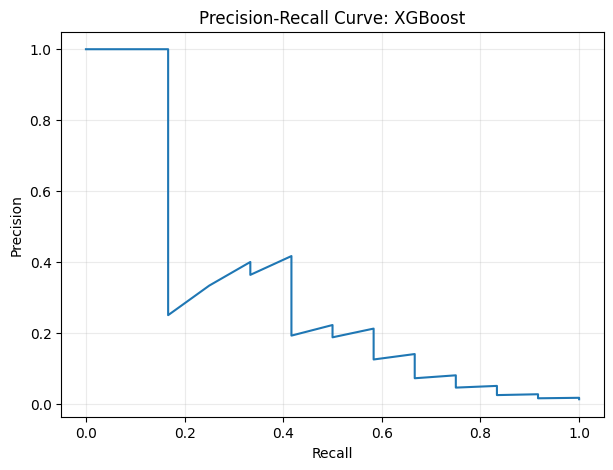

In [14]:
precision, recall, _ = precision_recall_curve(y_test, test_scores)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve: {best_model_name}')
plt.grid(alpha=0.25)
plt.show()

## 12. Feature importance

For tree models, the fitted model provides a simple measure of how often and how strongly each feature is used in its decisions. This is not a full causal explanation, but it is useful for understanding what the model relies on.

For Logistic Regression, the absolute coefficient sizes are shown instead.

,feature,importance
1,numeric__log_amount,0.160103
13,category__type_PAYMENT,0.144499
0,numeric__amount,0.113775
14,category__type_TRANSFER,0.099736
10,category__type_CASH_IN,0.090440
11,category__type_CASH_OUT,0.070157
5,numeric__amount_vs_sender_mean,0.059697
6,numeric__recipient_tx_count_before,0.051636
12,category__type_DEBIT,0.048139
2,numeric__hour,0.043426


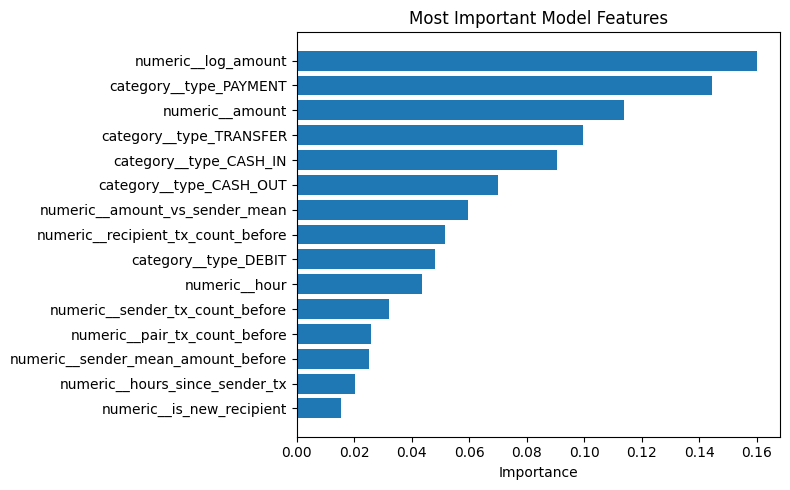

In [15]:
preprocess = best_model.named_steps['preprocess']
fitted_model = best_model.named_steps['model']
feature_names = preprocess.get_feature_names_out()

if hasattr(fitted_model, 'feature_importances_'):
    importance_values = fitted_model.feature_importances_
elif hasattr(fitted_model, 'coef_'):
    importance_values = np.abs(fitted_model.coef_[0])
else:
    importance_values = None

if importance_values is not None:
    feature_importance = (
        pd.DataFrame({'feature': feature_names, 'importance': importance_values})
          .sort_values('importance', ascending=False)
          .head(15)
    )
    display(feature_importance)

    plt.figure(figsize=(8, 5))
    plot_data = feature_importance.sort_values('importance')
    plt.barh(plot_data['feature'], plot_data['importance'])
    plt.xlabel('Importance')
    plt.title('Most Important Model Features')
    plt.tight_layout()
    plt.show()

## 13. Performance over time

A fraud model should not only be judged by one overall test score. This section divides the test period into several time blocks and checks whether the fraud rate, average model score and recall change noticeably.

Large changes do not automatically mean the model is broken, but they are a useful signal that the data or fraud behaviour may have changed.

In [16]:
monitor = test[['step', 'isFraud', 'amount']].copy()
monitor['score'] = test_scores
monitor['prediction'] = test_predictions
monitor['time_block'] = pd.qcut(
    monitor['step'].rank(method='first'),
    q=min(5, monitor['step'].nunique()),
    labels=False,
    duplicates='drop',
)

monitoring_rows = []
for block, part in monitor.groupby('time_block'):
    monitoring_rows.append({
        'time_block': int(block),
        'transactions': len(part),
        'fraud_rate': part['isFraud'].mean(),
        'average_model_score': part['score'].mean(),
        'recall': recall_score(part['isFraud'], part['prediction'], zero_division=0),
    })

monitoring = pd.DataFrame(monitoring_rows)
monitoring

,time_block,transactions,fraud_rate,average_model_score,recall
0,0,186,0.010753,0.011917,0.50
1,1,185,0.010811,0.007322,0.00
2,2,186,0.021505,0.010243,0.25
3,3,185,0.010811,0.010112,1.00
4,4,186,0.010753,0.008209,0.00


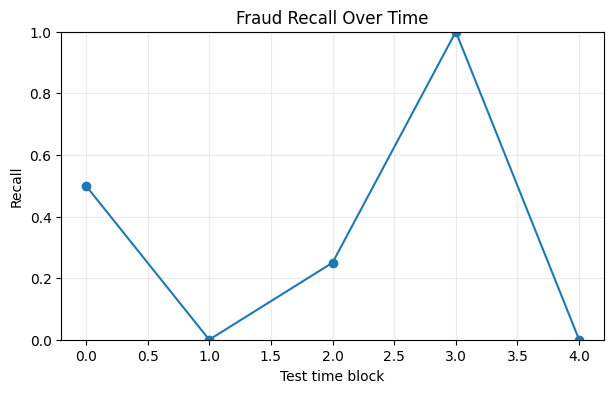

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(monitoring['time_block'], monitoring['recall'], marker='o')
plt.xlabel('Test time block')
plt.ylabel('Recall')
plt.title('Fraud Recall Over Time')
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.show()

## 14. Save the model and results

The saved model contains both preprocessing and the classifier, so the same transformations will be applied when new transactions are scored later.

A future deployment can load `fraud_model.joblib` inside a small FastAPI or Streamlit application.

In [18]:
from train_model import library_versions, save_artifacts

is_demo_artifact = DATA_PATH.resolve() == Path('demo_paysim.csv').resolve()
metadata = {
    'artifact_schema_version': 1,
    'model': best_model_name,
    'review_threshold': float(review_threshold),
    'review_capacity': REVIEW_CAPACITY,
    'features': MODEL_FEATURES,
    'test_metrics': {
        key: float(value) if isinstance(value, (np.floating, float)) else value
        for key, value in final_metrics.items()
    },
    'data_source': 'demo' if is_demo_artifact else 'PaySim CSV',
    'data_path': str(DATA_PATH.resolve()),
    'demo_data': is_demo_artifact,
    'deployment_warning': (
        'Demo-trained artifacts are for integration testing only.'
        if is_demo_artifact else None
    ),
    'library_versions': library_versions(),
}

saved_paths = save_artifacts(
    artifact_dir=ARTIFACT_DIR,
    model=best_model,
    validation_results=validation_results,
    monitoring=monitoring,
    metadata=metadata,
)

print('Saved files:')
for path in sorted(saved_paths):
    print('-', path)

Saved files:
- artifacts/fraud_model.joblib
- artifacts/model_metadata.json
- artifacts/monitoring_over_time.csv
- artifacts/validation_results.csv


## 15. Example scoring output

This final cell shows the type of output a deployment could return. Because the class-weighted candidates are not calibrated, the value is named `fraud_score`: use it for ranking and thresholding, not as a real-world fraud likelihood. The Streamlit and FastAPI deployment code remains separate from the modelling work.

In [19]:
example = test.iloc[[0]][MODEL_FEATURES]
example_score = best_model.predict_proba(example)[0, 1]

example_output = {
    'fraud_score': float(example_score),
    'send_for_review': bool(example_score >= review_threshold),
}

example_output

{'fraud_score': 0.00010002402996178716, 'send_for_review': False}